<a href="https://colab.research.google.com/github/ydchen17/PPI_Analysis_Project/blob/main/NetworkAnalysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
! pip install networkx
import networkx as nx
import pandas as pd

In [ ]:
#! wget https://stringdb-static.org/download/protein.links.v11.5/9606.protein.links.v11.5.txt.gz && gunzip 9606.protein.links.v11.5.txt.gz
#! wget https://stringdb-static.org/download/protein.links.v11.5/362663.protein.links.v11.5.txt.gz && gunzip 362663.protein.links.v11.5.txt.gz
#! wget https://stringdb-static.org/download/protein.links.v11.5/4932.protein.links.v11.5.txt.gz && gunzip 4932.protein.links.v11.5.txt.gz
#! wget https://stringdb-static.org/download/protein.links.v11.5/10090.protein.links.v11.5.txt.gz && gunzip 10090.protein.links.v11.5.txt.gz

! wget http://www.ebi.ac.uk/Tools/webservices/psicquic/mint/webservices/current/search/query/species:human
! wget http://www.ebi.ac.uk/Tools/webservices/psicquic/mint/webservices/current/search/query/species:mouse
! wget http://www.ebi.ac.uk/Tools/webservices/psicquic/mint/webservices/current/search/query/species:fruit%20fly
! wget http://www.ebi.ac.uk/Tools/webservices/psicquic/mint/webservices/current/search/query/species:yeast

--2021-10-11 04:49:59--  http://www.ebi.ac.uk/Tools/webservices/psicquic/mint/webservices/current/search/query/species:human
Resolving www.ebi.ac.uk (www.ebi.ac.uk)... 193.62.193.80
Connecting to www.ebi.ac.uk (www.ebi.ac.uk)|193.62.193.80|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/plain]
Saving to: ‘species:human’

species:human           [                <=> ]  64.46M   131KB/s    in 2m 21s  

2021-10-11 04:52:21 (469 KB/s) - ‘species:human’ saved [67592187]

--2021-10-11 04:52:21--  http://www.ebi.ac.uk/Tools/webservices/psicquic/mint/webservices/current/search/query/species:mouse
Resolving www.ebi.ac.uk (www.ebi.ac.uk)... 193.62.193.80
Connecting to www.ebi.ac.uk (www.ebi.ac.uk)|193.62.193.80|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/plain]
Saving to: ‘species:mouse’

species:mouse           [   <=>              ]  14.08M   197KB/s    in 78s     

2021-10-11 04:53:42 (185 KB/s) - ‘speci

In [ ]:
human_ppi_edges = pd.read_csv("/content/species:human", sep = "\t", header = None)
yeast_ppi_edges = pd.read_csv("/content/species:yeast", sep = "\t", header = None)
fly_ppi_edges = pd.read_csv("/content/species:fruit fly", sep = "\t", header = None)
mouse_ppi_edges = pd.read_csv("/content/species:mouse", sep = "\t", header = None)

In [ ]:
! cat /content/species:yeast | head

uniprotkb:P0CY12	uniprotkb:P0CY10	intact:EBI-8492802|intact:MINT-507217|uniprotkb:P01368|uniprotkb:P01367|uniprotkb:Q6B184|uniprotkb:D6VR97	intact:EBI-8492819|uniprotkb:Q06724|uniprotkb:P09091|uniprotkb:D6VR98|uniprotkb:P01366|intact:MINT-717801	psi-mi:mata2_yeasx(display_long)|uniprotkb:MATA2(gene name)|psi-mi:MATA2(display_short)	psi-mi:mata1_yeasx(display_long)|uniprotkb:MATA1(gene name)|psi-mi:MATA1(display_short)|uniprotkb:MAT1A(gene name synonym)	psi-mi:"MI:0114"(x-ray crystallography)	Ke et al. (2002)	pubmed:12121651|mint:MINT-5215552	taxid:4932(yeasx)|taxid:4932("Saccharomyces cerevisiae (Baker's yeast)")	taxid:4932(yeasx)|taxid:4932("Saccharomyces cerevisiae (Baker's yeast)")	psi-mi:"MI:0407"(direct interaction)	psi-mi:"MI:0471"(MINT)	intact:EBI-8492798|mint:MINT-24767	intact-miscore:0.44
uniprotkb:E9P8I0	uniprotkb:E9P8I0	intact:EBI-8509988|intact:MINT-8043936	intact:EBI-8509988|intact:MINT-8043936	psi-mi:e9p8i0_yeasx(display_long)|uniprotkb:URE2(gene name)|psi-mi:URE2(display

In [ ]:
human_ppi_nodes = list(set.union(set(human_ppi_edges[0]), set(human_ppi_edges[1])))
yeast_ppi_nodes = list(set.union(set(yeast_ppi_edges[0]), set(yeast_ppi_edges[1])))
fly_ppi_nodes = list(set.union(set(fly_ppi_edges[0]), set(fly_ppi_edges[1])))
mouse_ppi_nodes =  list(set.union(set(mouse_ppi_edges[0]), set(mouse_ppi_edges[1])))

In [ ]:
ppi_stats_dict = {"species":["Homo sapiens", "Mus musculus", "Saccharomyces cerevisiae", "Drosophila melanogaster"], 
                  "number of nodes":[len(human_ppi_nodes), len(mouse_ppi_nodes), len(yeast_ppi_nodes), len(fly_ppi_nodes)], 
                  "number of edges":[len(human_ppi_edges), len(mouse_ppi_edges), len(yeast_ppi_edges), len(fly_ppi_edges)]}

In [ ]:
pd.DataFrame(ppi_stats_dict)

,species,number of nodes,number of edges
0,Homo sapiens,13367,62772
1,Mus musculus,6780,15160
2,Saccharomyces cerevisiae,4972,42351
3,Drosophila melanogaster,664,986


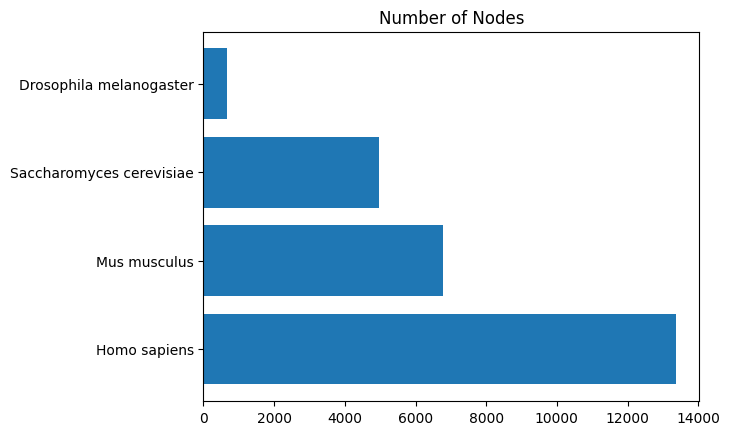

In [ ]:
import matplotlib.pyplot as plt
plt.rcdefaults()
fig, ax = plt.subplots()
ax.barh(ppi_stats_dict["species"], ppi_stats_dict["number of nodes"])
plt.title("Number of Nodes")
plt.show()

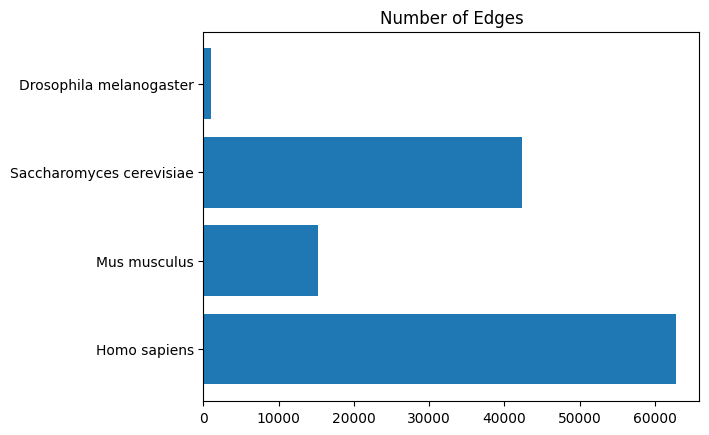

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.rcdefaults()
fig, ax = plt.subplots()
ax.barh(ppi_stats_dict["species"], ppi_stats_dict["number of edges"])
plt.title("Number of Edges")
plt.show()
plt.savefig("/Edge_Evo.png")

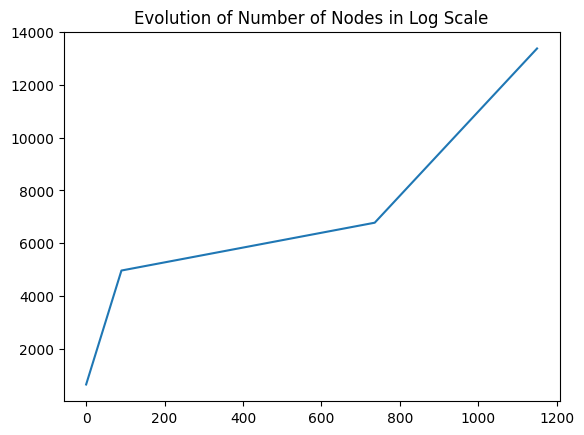

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.plot([1150, 736, 90, 0], ppi_stats_dict["number of nodes"])
plt.title("Evolution of Number of Nodes in Log Scale")
plt.show()

In [ ]:
import pandas as pd
import networkx as nx
def create_graph(edgelist):
  df = edgelist
  g = nx.from_pandas_edgelist(df, source=0, target=1)
  return g

import matplotlib.pyplot as plt
from collections import Counter
def plot_degree_dist(edgelist, title):
  g = create_graph(edgelist)
  degrees = [g.degree(n) for n in g.nodes()]
  counts = Counter(degrees)                                                                                                 
  x, y = zip(*counts.items())

  plt.figure(1)
  plt.title(title)
  plt.xlabel('Degree')
  plt.xscale('log')
  plt.xlim(1, max(x))

  plt.ylabel('Count')
  plt.yscale('log')
  plt.ylim(1, max(x))

  plt.scatter(x,y, marker='o')
  plt.show()

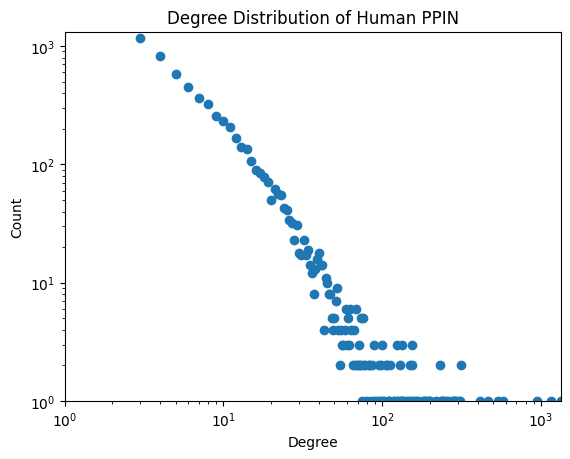

In [ ]:
plot_degree_dist(human_ppi_edges, "Degree Distribution of Human PPIN")

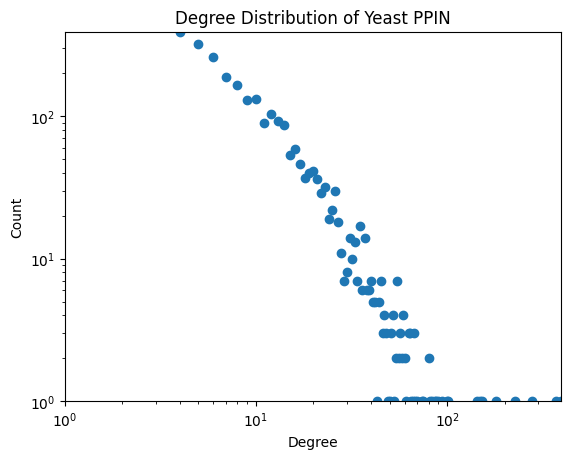

In [ ]:
plot_degree_dist(yeast_ppi_edges, "Degree Distribution of Yeast PPIN")

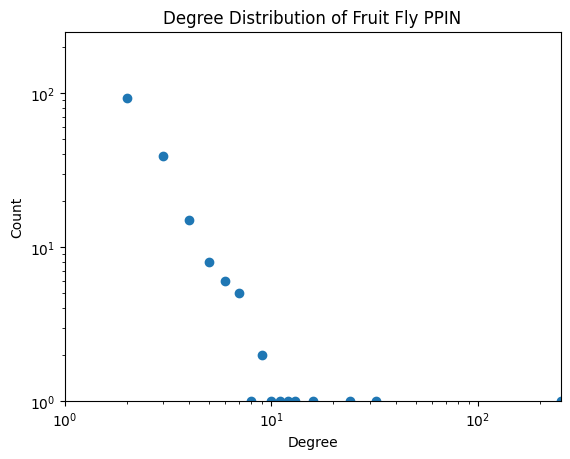

In [ ]:
plot_degree_dist(fly_ppi_edges, "Degree Distribution of Fruit Fly PPIN")

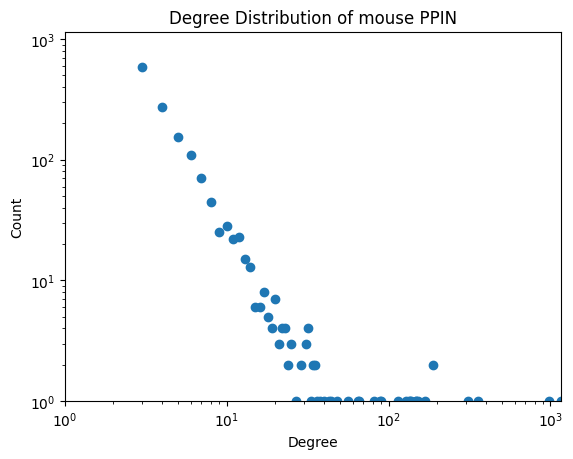

In [ ]:
plot_degree_dist(mouse_ppi_edges, "Degree Distribution of mouse PPIN")

In [ ]:
! wget http://www.hprd.org/RELEASE9/HPRD_Release9_041310.tar.gz

--2021-10-11 04:54:44--  http://www.hprd.org/RELEASE9/HPRD_Release9_041310.tar.gz
Resolving www.hprd.org (www.hprd.org)... 54.196.163.61
Connecting to www.hprd.org (www.hprd.org)|54.196.163.61|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 687774 (672K) [application/x-tar]
Saving to: ‘HPRD_Release9_041310.tar.gz’

HPRD_Release9_04131 100%[===================>] 671.65K   729KB/s    in 0.9s    

2021-10-11 04:54:45 (729 KB/s) - ‘HPRD_Release9_041310.tar.gz’ saved [687774/687774]



In [ ]:
!tar -zxvf HPRD_Release9_041310.tar.gz

HPRD_Release9_062910/
HPRD_Release9_062910/BINARY_PROTEIN_PROTEIN_INTERACTIONS.txt
HPRD_Release9_062910/README


In [ ]:
! cat HPRD_Release9_062910/BINARY_PROTEIN_PROTEIN_INTERACTIONS.txt | head

ALDH1A1	00001	NP_000680.2	ALDH1A1	00001	NP_000680.2	in vivo;yeast 2-hybrid	12081471,16189514
ITGA7	02761	NP_001138468.1	CHRNA1	00007	NP_001034612.1	in vivo	10910772
PPP1R9A	16000	NP_060120.2	ACTG1	00017	NP_001605.1	in vitro;in vivo	9362513,12052877
SRGN	01513	NP_002718.2	CD44	00115	NP_000601.3	in vivo	9334256
GRB7	03311	NP_005301.2	ERBB2	01281	NP_004439.2	in vitro;in vivo	9079677
PAK1	03995	AAC24716.1	ERBB2	01281	NP_004439.2	in vivo	9774445
DLG4	04199	NP_001356.1	ERBB2	01281	NP_004439.2	in vivo;yeast 2-hybrid	10839362
PIK3R2	04404	NP_005018.1	ERBB2	01281	NP_004439.2	in vivo	1334406
PTPN18	05961	NP_055184.2	ERBB2	01281	NP_004439.2	in vitro	14660651
ERBB2IP	06090	AAK69431.1	ERBB2	01281	NP_004439.2	in vitro;in vivo	11278603,10878805


In [ ]:
! cat HPRD_Release9_062910/README


#########################################################################
#                                                                       #
#  Human Protein Reference Database                                     #
#                                                                       #
#  Copyright (C) 2002-09, Johns Hopkins University and                  #
#                         The Institute of Bioinformatics.              #
#                                                                       #
#  This code is licensed under the GNU Lesser General Public License.   #
#  See the file LICENSE or this URL for the full text of the license:   #
#  http://www.gnu.org/licenses/lgpl.html                                #
#                                                                       #
#########################################################################

Number of files = 1
1. BINARY_PROTEIN_PROTEIN_INTERACTIONS.txt

This file stores all the binary protein protei

In [ ]:
human_ppi_edges1 = pd.read_csv("HPRD_Release9_062910/BINARY_PROTEIN_PROTEIN_INTERACTIONS.txt", sep = "\t", header=None)

In [ ]:
human_ppi_edges1[[0,3]]

,0,3
0,ALDH1A1,ALDH1A1
1,ITGA7,CHRNA1
2,PPP1R9A,ACTG1
3,SRGN,CD44
4,GRB7,ERBB2
...,...,...
39235,SHC1,ERBB2
39236,IL6ST,ERBB2
39237,PTK2,ERBB2
39238,CAV1,ERBB2


In [ ]:
# plot_degree_dist(human_ppi_edges1[[0,3]], "Degree Distribution of Human PPIN (HPRD)")

In [ ]:
#! wget http://www.ebi.ac.uk/Tools/webservices/psicquic/mint/webservices/current/search/query/species:human
#! wget http://www.ebi.ac.uk/Tools/webservices/psicquic/mint/webservices/current/search/query/species:mouse
#! wget http://www.ebi.ac.uk/Tools/webservices/psicquic/mint/webservices/current/search/query/species:fruit%20fly
#! wget http://www.ebi.ac.uk/Tools/webservices/psicquic/mint/webservices/current/search/query/species:yeast

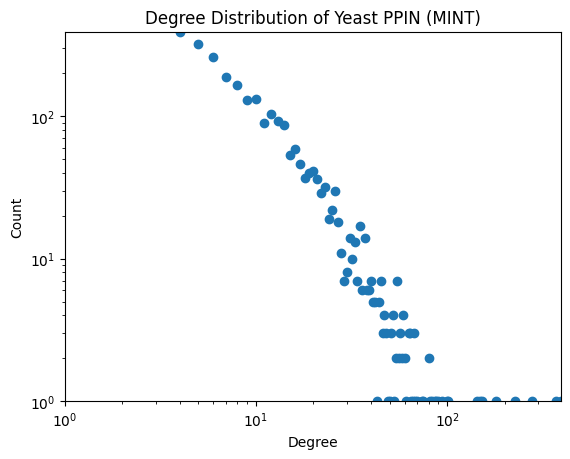

In [ ]:
plot_degree_dist(pd.read_csv("/content/species:yeast",sep="\t", header = None)[[0,1]], "Degree Distribution of Yeast PPIN (MINT)")

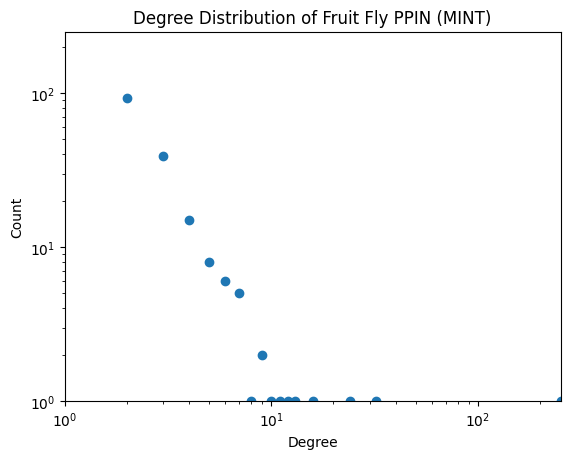

In [ ]:
plot_degree_dist(pd.read_csv("/content/species:fruit fly",sep="\t", header = None)[[0,1]], "Degree Distribution of Fruit Fly PPIN (MINT)")

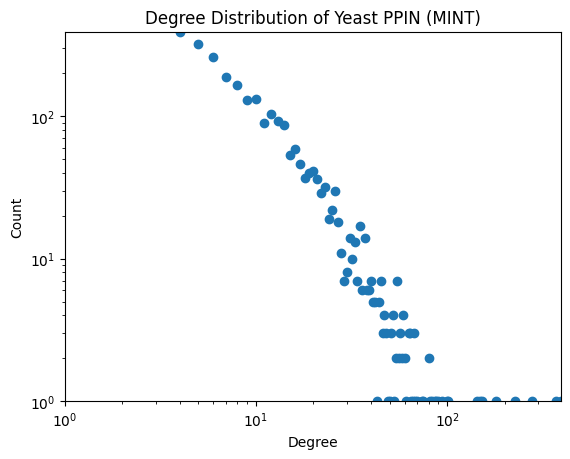

In [ ]:
plot_degree_dist(pd.read_csv("/content/species:yeast",sep="\t", header = None)[[0,1]], "Degree Distribution of Yeast PPIN (MINT)")

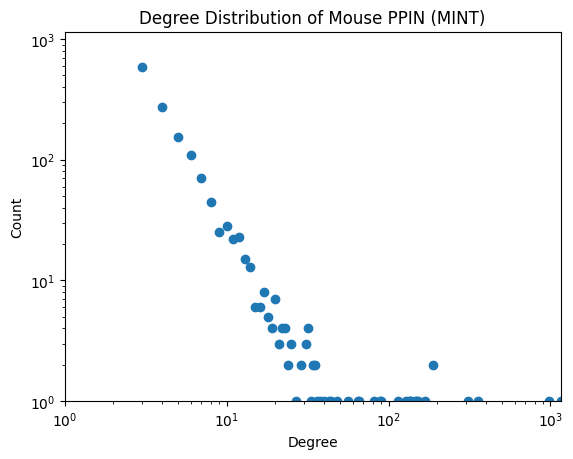

In [ ]:
plot_degree_dist(pd.read_csv("/content/species:mouse",sep="\t", header = None)[[0,1]], "Degree Distribution of Mouse PPIN (MINT)")

In [ ]:
import networkx as nx
human_ppi = nx.from_pandas_edgelist(human_ppi_edges, 0, 1) #, ["combined_score"])
# Do not use combined_score. They are not weight! See https://string-db.org/cgi/info
nx.info(human_ppi)
yeast_ppi = nx.from_pandas_edgelist(yeast_ppi_edges, 0, 1) #, ["combined_score"])
nx.info(yeast_ppi)

'Graph with 4972 nodes and 19545 edges'

In [ ]:
print(nx.average_clustering(yeast_ppi))
print(nx.average_clustering(human_ppi))
print(nx.average_clustering(create_graph(fly_ppi_edges)))
print(nx.average_clustering(create_graph(mouse_ppi_edges)))

df = pd.DataFrame({"species":["yeast","human","fly","mouse"], 
              "Average Clustering Coefficient":[nx.average_clustering(yeast_ppi),
                                                nx.average_clustering(human_ppi),
                                                nx.average_clustering(create_graph(fly_ppi_edges)),
                                                nx.average_clustering(create_graph(mouse_ppi_edges))]})

0.22720523980537866
0.07051716738995577
0.09151500785497461
0.03948281068275479


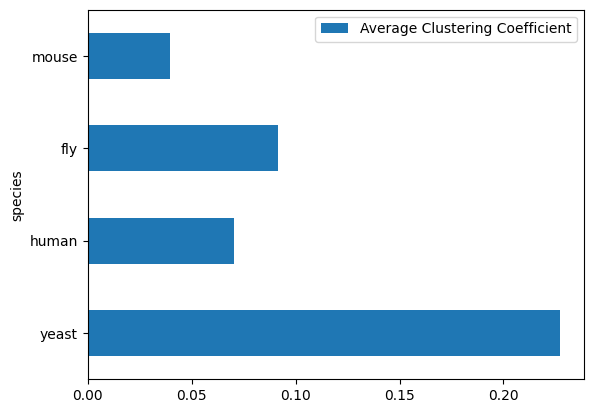

In [ ]:
df.set_index('species').plot(kind="barh")

In [ ]:
len(pd.read_csv("/content/species:human",sep="\t", header = None)[[0,1]].index)

62772

In [ ]:
create_graph

<function __main__.create_graph>

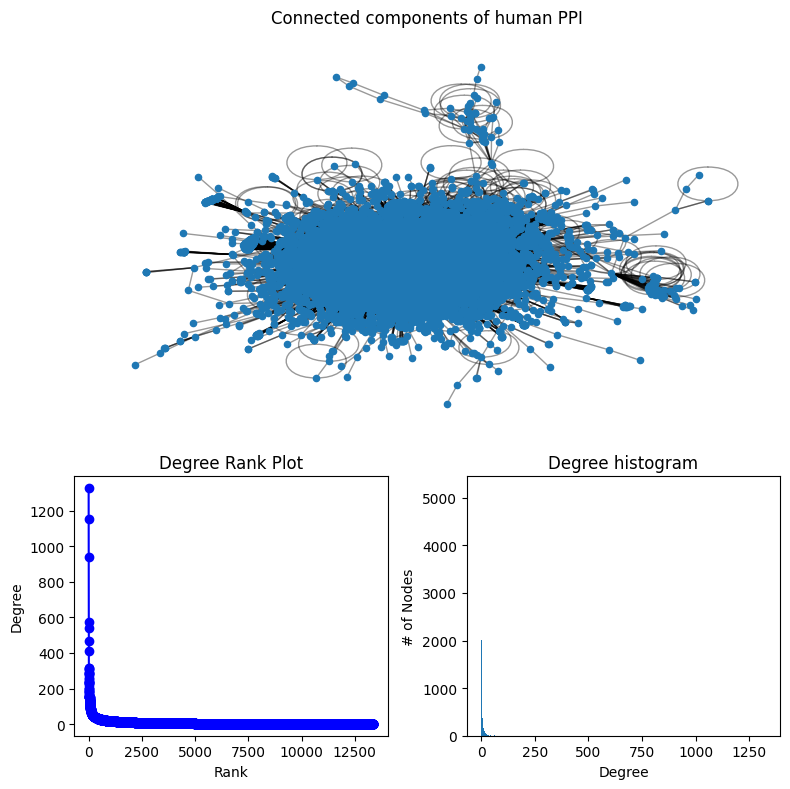

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

human_degree_sequence = sorted([d for n, d in human_ppi.degree()], reverse=True)
human_dmax = max(human_degree_sequence)

fig = plt.figure("Degree of human PPI", figsize=(8, 8))
# Create a gridspec for adding subplots of different sizes
axgrid = fig.add_gridspec(5, 4)

ax0 = fig.add_subplot(axgrid[0:3, :])
Gcc = human_ppi.subgraph(sorted(nx.connected_components(human_ppi), key=len, reverse=True)[0])
pos = nx.spring_layout(Gcc)
nx.draw_networkx_nodes(Gcc, pos, ax=ax0, node_size=20)
nx.draw_networkx_edges(Gcc, pos, ax=ax0, alpha=0.4)
ax0.set_title("Connected components of human PPI")
ax0.set_axis_off()

ax1 = fig.add_subplot(axgrid[3:, :2])
ax1.plot(human_degree_sequence, "b-", marker="o")
ax1.set_title("Degree Rank Plot")
ax1.set_ylabel("Degree")
ax1.set_xlabel("Rank")

ax2 = fig.add_subplot(axgrid[3:, 2:])
ax2.bar(*np.unique(human_degree_sequence, return_counts=True))
ax2.set_title("Degree histogram")
ax2.set_xlabel("Degree")
ax2.set_ylabel("# of Nodes")

fig.tight_layout()
plt.show()

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:29: UserWarning: Attempted to set non-positive left xlim on a log-scaled axis.
Invalid limit will be ignored.
/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).
  warnings.warn(msg, FutureWarning)


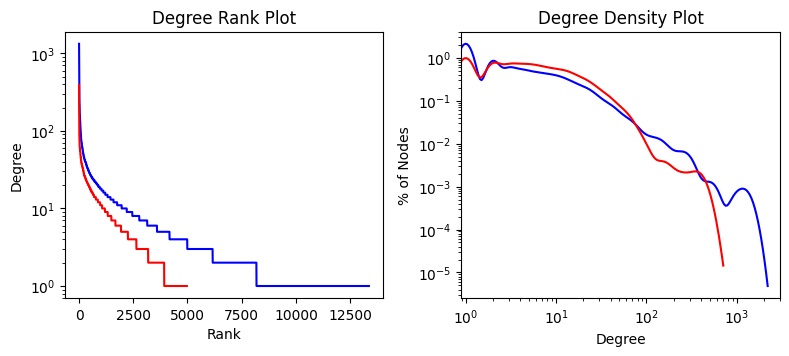

In [ ]:
yeast_degree_sequence = sorted([d for n, d in yeast_ppi.degree()], reverse=True)
yeast_dmax = max(yeast_degree_sequence)
human_degree_sequence = sorted([d for n, d in human_ppi.degree()], reverse=True)
human_dmax = max(human_degree_sequence)


fig = plt.figure("Degree of yeast PPI", figsize=(8, 8))
# Create a gridspec for adding subplots of different sizes
axgrid = fig.add_gridspec(5, 4)

ax1 = fig.add_subplot(axgrid[3:, :2])
ax1.plot(human_degree_sequence, "blue")
ax1.plot(yeast_degree_sequence, "red")
ax1.set_title("Degree Rank Plot")
ax1.set_yscale("log")
ax1.set_ylabel("Degree")
ax1.set_xlabel("Rank")


ax2 = fig.add_subplot(axgrid[3:, 2:])
#ax2.barh(*np.unique(human_degree_sequence, return_counts=True), color="blue")
#ax2.barh(*np.unique(yeast_degree_sequence, return_counts=True), color="red")
ax2.set_xscale("log")
ax2.set_yscale("log")

ax2.set_title("Degree Density Plot")
ax2.set_xlabel("Degree")
ax2.set_ylabel("% of Nodes")
plt.xlim([0,3000])
import seaborn as sns
sns.distplot(human_degree_sequence, hist=False, color="blue")
sns.distplot(yeast_degree_sequence, hist=False, color="red")


fig.tight_layout()
plt.show()

In [ ]:
# https://snap.stanford.edu/snappy
#! pip install snap-stanford
#! sudo apt install graphviz gnuplot
import pandas as pd

human_ppi_edges = pd.read_csv("/content/species:human", sep = "\t", header = None)
yeast_ppi_edges = pd.read_csv("/content/species:yeast", sep = "\t", header = None)
fly_ppi_edges = pd.read_csv("/content/species:fruit fly", sep = "\t", header = None)
mouse_ppi_edges = pd.read_csv("/content/species:mouse", sep = "\t", header = None)

human_ppi_edges[[0,1]].rename(columns={0: "protein1", 1: "protein2"}).to_csv("/content/drive/MyDrive/Network_GroupProject/MINT_human_ppi_edges2.csv", index = False)
yeast_ppi_edges[[0,1]].rename(columns={0: "protein1", 1: "protein2"}).to_csv("/content/drive/MyDrive/Network_GroupProject/MINT_yeast_ppi_edges2.csv", index = False)

FileNotFoundError: ignored

In [ ]:
len(pd.read_csv("/content/drive/MyDrive/Network_GroupProject/MINT_human_ppi_edges2.csv"))

In [ ]:
def nodelist(edge_list):
  return list(set.union(set(edge_list["protein1"]), set(edge_list["protein2"])))

In [ ]:
human_ppi_edges = pd.read_csv("/content/drive/MyDrive/Network_GroupProject/MINT_human_ppi_edges2.csv")
human_ppi_nodes = nodelist(human_ppi_edges)

yeast_ppi_edges = pd.read_csv("/content/drive/MyDrive/Network_GroupProject/MINT_yeast_ppi_edges2.csv")
yeast_ppi_nodes = nodelist(yeast_ppi_edges)

In [ ]:
yeast_ppi_edges["protein1"][1].split(":")[1]

In [ ]:
print(len(human_ppi_nodes),len(human_ppi_edges))

In [ ]:
print(len(yeast_ppi_nodes),len(yeast_ppi_edges))

In [ ]:
# yeast_ppi_nodes

In [ ]:
print(len(yeast_ppi_nodes),len(yeast_ppi_edges))

In [ ]:
print(len(human_ppi_nodes),len(human_ppi_edges))

In [ ]:
print(len(yeast_ppi_nodes),len(yeast_ppi_edges))

In [ ]:
yeast_ppi_nodes_simple = [i.split(":")[1] for i in yeast_ppi_nodes]
human_ppi_nodes_simple = [i.split(":")[1] for i in human_ppi_nodes]
# human_ppi_nodes_not_uniprot = [i for i in human_ppi_nodes if len(i.split(":")) == 1]
# human_ppi_nodes.remove("-")

print(len(yeast_ppi_nodes_simple), len(human_ppi_nodes_simple), len(human_ppi_nodes_not_uniprot))

In [ ]:
with open("/content/drive/MyDrive/Network_GroupProject/new_Data/human_ppi_nodes.txt") as 

In [ ]:
! pip install gprofiler-official
from gprofiler import GProfiler

gp = GProfiler(return_dataframe=True)
gp.convert(organism='scerevisiae',query=yeast_ppi_nodes_simple,target_namespace='ENSG')["converted"].to_csv("yeast_all_ENSG.txt", index = None, header = None)
gp.convert(organism='hsapiens',query=human_ppi_nodes_simple,target_namespace='ENSG')["converted"].to_csv("human_all_ENSG.txt", index = None, header = None)

In [ ]:
! pip install gprofiler-official

from gprofiler import GProfiler
gp = GProfiler(return_dataframe=True)
orth = gp.orth(organism='scerevisiae',
            query=yeast_ppi_nodes_simple,
            target='hsapiens')

In [ ]:
print(len(yeast_ppi_nodes_simple), len(orth))

In [ ]:
orth

In [ ]:
query_list = list(set(orth[["ortholog_ensg"]].transpose().to_numpy().tolist()[0]))
human_ENSG2UniProt = gp.convert(organism='hsapiens',query=query_list,target_namespace='UNIPROTSWISSPROT_ACC')[["incoming","converted"]].rename(columns = {"incoming":"human_ENSG", "converted":"human_UniProtKB"})
human_ENSG2UniProt

In [ ]:
import urllib

def uniprot_mapping(fromtype, totype, identifier):
    """Takes an identifier, and types of identifier 
    (to and from), and calls the UniProt mapping service"""
    base = 'http://www.uniprot.org'
    tool = 'mapping'
    params = {'from':fromtype,
                'to':totype,
                'format':'tab',
                'query':identifier,
    }
    #urllib turns the dictionary params into an encoded url suffix
    data = urllib.urlencode(params)
    #construct the UniProt URL
    url = base+'/'+tool+'?'+data
    #and grab the mapping
    response = urllib.urlopen(url)
    #response.read() provides tab-delimited output of the mapping
    return response.read()

In [ ]:
yeast_to_human_orth = orth[["incoming",'converted','ortholog_ensg']].rename(columns = {"incoming":"Yeast_UniProtKB", "converted":"yeast_ENSG"})

In [ ]:
yeast_to_human_orth =yeast_to_human_orth.set_index('ortholog_ensg').join(human_ENSG2UniProt.set_index("human_ENSG"))

In [ ]:
yeast_to_human_orth["human_ENSG"]=yeast_to_human_orth.index

In [ ]:
# yeast_to_human_orth = yeast_to_human_orth.reset_index(drop=True)

In [ ]:
yeast_to_human_orth["human_UniProtKB"]

In [ ]:
def check_node(node,ppin):
  if node in ppin:
    return True
  else:
    return False

In [ ]:
#human_ppi_nodes

In [ ]:
yeast_to_human_orth["human PPIN check"] = yeast_to_human_orth["human_UniProtKB"].map(lambda x: "uniprotkb:"+x in human_ppi_nodes)

In [ ]:
yeast_to_human_orth = yeast_to_human_orth[yeast_to_human_orth["human PPIN check"]==True].reset_index(drop=True)

In [ ]:
print(len(set(yeast_to_human_orth["Yeast_UniProtKB"].to_numpy().tolist())),
      len(set(yeast_to_human_orth["human_UniProtKB"].to_numpy().tolist())))

In [ ]:
pd.DataFrame(set(yeast_to_human_orth["human_UniProtKB"].to_numpy().tolist())).to_csv("human_conserved.txt", header = None, index = None)
pd.DataFrame(set(yeast_to_human_orth["human_ENSG"].to_numpy().tolist())).to_csv("human_conserved_ENSG.txt", header = None, index = None)

In [ ]:
pd.DataFrame(set(yeast_to_human_orth["Yeast_UniProtKB"].to_numpy().tolist())).to_csv("yeast_conserved.txt", header = None, index = None)
pd.DataFrame(set(yeast_to_human_orth["yeast_ENSG"].to_numpy().tolist())).to_csv("yeast_conserved_ENSG.txt", header = None, index = None)

In [ ]:
yeast_to_human_orth["human_UniProtKB"].drop_duplicates()

In [ ]:
yeast_conserved = yeast_to_human_orth.drop_duplicates("converted")["incoming"].to_numpy().tolist()
yeast_specific = [node for node in yeast_to_human_orth.drop_duplicates("incoming")["incoming"] if (node not in yeast_conserved)]      

In [ ]:
human_conserved_mapped = set(yeast_to_human_orth.drop_duplicates("converted")["converted"].to_numpy().tolist())
human_conserved = [protein for protein in human_conserved_mapped if protein in human_ppi_nodes]
human_specific = [protein for protein in human_ppi_nodes if protein not in human_conserved]

In [ ]:
len(human_conserved_mapped)

In [ ]:
len(human_conserved)

In [ ]:
len(set(human_conserved)) - len(set(human_ppi_nodes))

In [ ]:
len(human_ppi_nodes)

In [ ]:
len(yeast_specific)
yeast_specific_ENSG = gp.convert(organism='scerevisiae',query=yeast_specific,target_namespace='ENSG')["converted"].to_numpy().tolist()
len(yeast_specific_ENSG)

In [ ]:
path_prefix = "/content/drive/MyDrive/Network_GroupProject/new_Data/"

def list_to_txt(mylist, location):
  textfile = open(location, "w")
  for line in mylist:
    textfile.write(line + "\n")
  textfile.close()

list_to_txt(human_conserved, path_prefix+"human_conserved.txt")
list_to_txt(human_specific, path_prefix+"human_specific.txt")
list_to_txt(yeast_conserved, path_prefix+"yeast_conserved.txt")
list_to_txt(yeast_specific, path_prefix+"yeast_specific.txt")

list_to_txt(yeast_ppi_nodes, path_prefix+"yeast_all.txt")
list_to_txt(human_ppi_nodes, path_prefix+"human_all.txt")

In [ ]:
def neig(node, net):
  return set([n for n in net.neighbors(node)])

def neig_count(node1, node2, net):
  node1_neig = neig(node1, net)
  node2_neig = neig(node2, net)
  intersec_neig = set(node1_neig).intersection(set(node2_neig))
  return len(node1_neig), len(node2_neig), len(intersec_neig)

def intersec_neig(node1, node2, net):
  node1_neig = set([n for n in net.neighbors(node1)])
  node2_neig = set([n for n in net.neighbors(node2)])
  intersec_neig = set(node1_neig).intersection(set(node2_neig))
  return intersec_neig

# Adjusted CD Distance
def adj_CD(node1, node2, net, avg_degree):
  # avg_degree = sum(pd.DataFrame(net.degree())[1])/len(pd.DataFrame(net.degree())[0])
  node1_neig = set([n for n in net.neighbors(node1)])
  node2_neig = set([n for n in net.neighbors(node2)])
  intersec_neig = set(node1_neig).intersection(set(node2_neig))
  lambdaU = max(0, avg_degree-len(node1_neig))
  lambdaV = max(0, avg_degree-len(node2_neig))
  distance = 2*len(intersec_neig)/(len(node1_neig)+len(node2_neig)+lambdaU+lambdaV)
  return distance

# neig_count("9606.ENSP00000075120", "9606.ENSP00000369213", human_ppi)
# intersec_neig("9606.ENSP00000075120", "9606.ENSP00000369213", human_ppi)

In [ ]:
# for the use of progress bar, please read https://zhuanlan.zhihu.com/p/403641309
!pip install tqdm
from tqdm.notebook import tqdm 
tqdm.pandas(desc="How stupid this script is!")

# Let's make this simpler: just get the CD distance of the edge list
human_avg_degree = sum(pd.DataFrame(human_ppi.degree())[1])/len(pd.DataFrame(human_ppi.degree())[0])
human_node_num = len(human_ppi_nodes)
human_ppi_edges["CD_distance"] = human_ppi_edges.progress_apply(lambda row: adj_CD(row["protein1"], row["protein2"], human_ppi, human_avg_degree), axis = 1)

yeast_avg_degree = sum(pd.DataFrame(yeast_ppi.degree())[1])/len(pd.DataFrame(yeast_ppi.degree())[0])
yeast_node_num = len(yeast_ppi_nodes)
yeast_ppi_edges["CD_distance"] = yeast_ppi_edges.progress_apply(lambda row: adj_CD(row["protein1"], row["protein2"], yeast_ppi, yeast_avg_degree), axis = 1)

How stupid this script is!:   0%|          | 0/5000 [00:00<?, ?it/s]

How stupid this script is!:   0%|          | 0/7000 [00:00<?, ?it/s]

In [ ]:
from gprofiler import GProfiler
gp = GProfiler(return_dataframe=True)
gp.profile(organism='hsapiens',
            query=human_specific)

,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents
0,GO:CC,GO:0043229,intracellular organelle,4.223771e-47,True,"""Organized structure of distinctive morphology...",13117,1078,947,18964,0.878479,0.072196,query_1,"[GO:0005622, GO:0043226]"
1,GO:CC,GO:0043226,organelle,1.675663e-44,True,"""Organized structure of distinctive morphology...",14027,1078,980,18964,0.909091,0.069865,query_1,[GO:0110165]
2,GO:MF,GO:0005515,protein binding,8.557349e-43,True,"""Interacting selectively and non-covalently wi...",14767,1080,1016,18679,0.940741,0.068802,query_1,[GO:0005488]
3,GO:CC,GO:0005622,intracellular anatomical structure,2.077817e-38,True,"""A component of a cell contained within (but n...",14808,1078,1000,18964,0.927644,0.067531,query_1,[GO:0110165]
4,GO:CC,GO:0043231,intracellular membrane-bounded organelle,2.460378e-38,True,"""Organized structure of distinctive morphology...",12046,1078,880,18964,0.816327,0.073053,query_1,"[GO:0043227, GO:0043229]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1702,TF,TF:M00450,Factor: Zic3; motif: NGGGKGGTC,4.969369e-02,True,Factor: Zic3; motif: NGGGKGGTC,14133,1101,842,19917,0.764759,0.059577,query_1,[TF:M00000]
1703,CORUM,CORUM:2692,SMAD3-SMAD4-cJun-cFos complex,4.977827e-02,True,SMAD3-SMAD4-cJun-cFos complex,4,430,4,3627,0.009302,1.000000,query_1,[CORUM:0000000]
1704,CORUM,CORUM:1148,snRNP-free U1A (SF-A) complex,4.977827e-02,True,snRNP-free U1A (SF-A) complex,4,430,4,3627,0.009302,1.000000,query_1,[CORUM:0000000]
1705,GO:CC,GO:0001772,immunological synapse,4.982015e-02,True,"""An area of close contact between a lymphocyte...",44,1078,10,18964,0.009276,0.227273,query_1,"[GO:0005886, GO:0110165]"


In [ ]:
gp.convert(organism='scerevisiae',query=yeast_conserved,target_namespace='ENSG')["converted"].to_csv("yeast_conserved_ENSG.txt", index = None, header = None)
gp.convert(organism='scerevisiae',query=yeast_specific,target_namespace='ENSG')["converted"].to_csv("yeast_specific_ENSG.txt", index = None, header = None)
gp.convert(organism='hsapiens',query=human_conserved,target_namespace='ENSP')["converted"].to_csv("human_conserved_ENSP.txt", index = None, header = None)
gp.convert(organism='hsapiens',query=human_specific,target_namespace='ENSP')["converted"].to_csv("human_specific_ENSP.txt", index = None, header = None)

In [ ]:
import urllib.parse
import urllib.request

url = 'https://www.uniprot.org/uploadlists/'

params = {
'from': 'ACC+ID',
'to': 'ENSEMBL_ID',
'format': 'tab',
'query': 'P40925 P40926 O43175 Q9UM73 P97793'
}

data = urllib.parse.urlencode(params)
data = data.encode('utf-8')
req = urllib.request.Request(url, data)
with urllib.request.urlopen(req) as f:
   response = f.read()
print(response.decode('utf-8'))